In [37]:
# Decision Tree: Rain Prediction
# Rain: no rain = 0, rain = 1

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

In [39]:
daily = pd.read_csv("daily.csv")

print(daily.shape)
daily.head()

(4085, 26)


,WindDir_CALM,WindDir_E,WindDir_ENE,WindDir_ESE,WindDir_N,WindDir_NE,WindDir_NNE,WindDir_NNW,WindDir_NW,WindDir_S,...,WindDir_WSW,Air Temp (degrees C),Humidity (%),MSLP (hPa),Wind Speed (km/h),Wind Gust (km/h),E (hPa),Dew Pt Temp (degrees C),Apparent Temp (degrees C),Rainfall since 9 am (mm)
0,0.0,0.0,0.03876,0.015504,0.007752,0.015504,0.007752,0.000000,0.023256,0.418605,...,0.038760,19.651938,61.635659,1011.784496,14.325581,43.0,13.980619,12.004651,0.0,0.0
1,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.563380,...,0.000000,18.560563,53.718310,1015.983099,22.704225,39.0,11.300188,8.839437,0.0,0.0
2,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,17.300000,51.000000,1016.400000,26.000000,35.0,10.048411,7.100000,0.0,0.0
3,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.008696,0.000000,0.278261,...,0.026087,17.183478,59.608696,1012.045217,15.782609,37.0,11.574564,9.133043,0.0,0.0
4,0.0,0.0,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.007752,0.418605,...,0.093023,18.110853,66.565891,1010.086047,19.837209,37.0,13.699222,11.719380,0.0,0.0


In [41]:
daily.columns

Index(['WindDir_CALM', 'WindDir_E', 'WindDir_ENE', 'WindDir_ESE', 'WindDir_N',
       'WindDir_NE', 'WindDir_NNE', 'WindDir_NNW', 'WindDir_NW', 'WindDir_S',
       'WindDir_SE', 'WindDir_SSE', 'WindDir_SSW', 'WindDir_SW', 'WindDir_W',
       'WindDir_WNW', 'WindDir_WSW', 'Air Temp (degrees C)', 'Humidity (%)',
       'MSLP (hPa)', 'Wind Speed (km/h)', 'Wind Gust  (km/h)', 'E (hPa)',
       'Dew Pt Temp (degrees C)', 'Apparent Temp (degrees C)',
       'Rainfall since 9 am (mm)'],
      dtype='object')

In [43]:

daily = pd.read_csv("daily.csv")

daily["RainTomorrow"] = np.where(
    daily["Rainfall since 9 am (mm)"].shift(-1) > 0,
    1,
    0
)

daily = daily.iloc[:-1]

X = daily.drop("RainTomorrow", axis=1)
y = daily["RainTomorrow"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (4084, 26)
y shape: (4084,)


In [45]:
X.isnull().sum()

WindDir_CALM                 388
WindDir_E                    388
WindDir_ENE                  388
WindDir_ESE                  388
WindDir_N                    388
WindDir_NE                   388
WindDir_NNE                  388
WindDir_NNW                  388
WindDir_NW                   388
WindDir_S                    388
WindDir_SE                   388
WindDir_SSE                  388
WindDir_SSW                  388
WindDir_SW                   388
WindDir_W                    388
WindDir_WNW                  388
WindDir_WSW                  388
Air Temp (degrees C)         388
Humidity (%)                 388
MSLP (hPa)                   388
Wind Speed (km/h)            388
Wind Gust  (km/h)            388
E (hPa)                      388
Dew Pt Temp (degrees C)      388
Apparent Temp (degrees C)    388
Rainfall since 9 am (mm)       0
dtype: int64

In [47]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (3063, 26)
Testing set: (1021, 26)


In [49]:
from sklearn.tree import DecisionTreeClassifier

dtc = DecisionTreeClassifier(random_state=42)

dtc = dtc.fit(X_train, y_train)

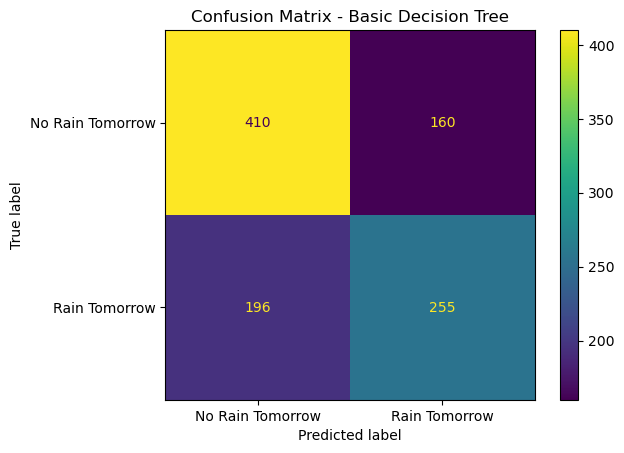

Basic Decision Tree Results
Accuracy: 0.651
Precision: 0.614
Recall: 0.565
F1-score: 0.589
ROC-AUC: 0.649

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.72      0.70       570
           1       0.61      0.57      0.59       451

    accuracy                           0.65      1021
   macro avg       0.65      0.64      0.64      1021
weighted avg       0.65      0.65      0.65      1021



In [51]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)


y_pred = dtc.predict(X_test)
y_pred_proba = dtc.predict_proba(X_test)[:, 1]


cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Rain Tomorrow", "Rain Tomorrow"]
)

disp.plot()
plt.title("Confusion Matrix - Basic Decision Tree")
plt.show()

# Evaluation metrics

print("Basic Decision Tree Results")
print("Accuracy:", np.round(accuracy_score(y_test, y_pred), 3))
print("Precision:", np.round(precision_score(y_test, y_pred), 3))
print("Recall:", np.round(recall_score(y_test, y_pred), 3))
print("F1-score:", np.round(f1_score(y_test, y_pred), 3))
print("ROC-AUC:", np.round(roc_auc_score(y_test, y_pred_proba), 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

In [53]:
depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

accuracy_scores = []

for depth in depths:
    dtc_depth = DecisionTreeClassifier(
        random_state=42,
        max_depth=depth
    )
    
    dtc_depth = dtc_depth.fit(X_train, y_train)
    
    y_pred_depth = dtc_depth.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred_depth)
    
    accuracy_scores.append(accuracy)

depth_results = pd.DataFrame({
    "max_depth": depths,
    "accuracy": accuracy_scores
})

depth_results

,max_depth,accuracy
0,1,0.677767
1,2,0.677767
2,3,0.676787
3,4,0.680705
4,5,0.677767
5,6,0.684623
6,7,0.691479
7,8,0.683643
8,9,0.677767
9,10,0.666014


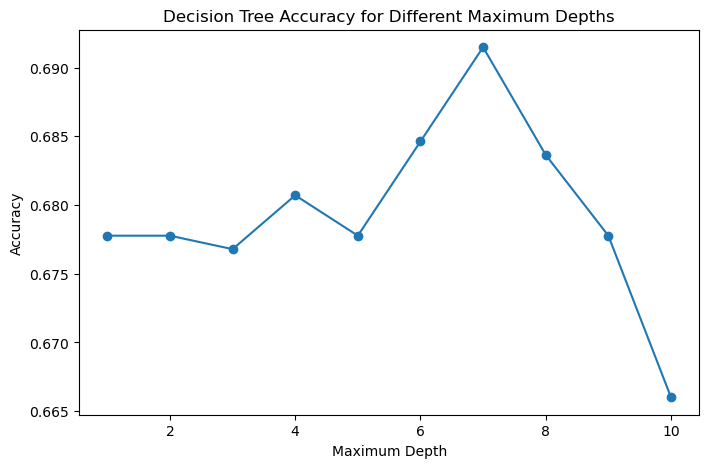

In [55]:
plt.figure(figsize=(8, 5))

plt.plot(
    depth_results["max_depth"],
    depth_results["accuracy"],
    marker="o"
)

plt.xlabel("Maximum Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Accuracy for Different Maximum Depths")

plt.show()

Best max_depth: 7


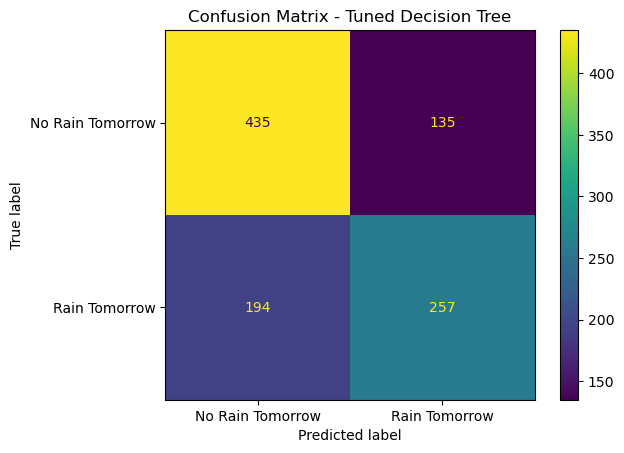

Tuned Decision Tree Results
Accuracy: 0.678
Precision: 0.656
Recall: 0.57
F1-score: 0.61
ROC-AUC: 0.726

Classification Report:
              precision    recall  f1-score   support

           0       0.69      0.76      0.73       570
           1       0.66      0.57      0.61       451

    accuracy                           0.68      1021
   macro avg       0.67      0.67      0.67      1021
weighted avg       0.68      0.68      0.67      1021



In [57]:
best_depth = depth_results.loc[
    depth_results["accuracy"].idxmax(),
    "max_depth"
]

print("Best max_depth:", best_depth)

dtc_tuned = DecisionTreeClassifier(
    random_state=42,
    max_depth=best_depth,
    min_samples_leaf=10
)

dtc_tuned = dtc_tuned.fit(X_train, y_train)


y_pred_tuned = dtc_tuned.predict(X_test)
y_pred_proba_tuned = dtc_tuned.predict_proba(X_test)[:, 1]


cm_tuned = confusion_matrix(y_test, y_pred_tuned)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tuned,
    display_labels=["No Rain Tomorrow", "Rain Tomorrow"]
)

disp.plot()
plt.title("Confusion Matrix - Tuned Decision Tree")
plt.show()


print("Tuned Decision Tree Results")
print("Accuracy:", np.round(accuracy_score(y_test, y_pred_tuned), 3))
print("Precision:", np.round(precision_score(y_test, y_pred_tuned), 3))
print("Recall:", np.round(recall_score(y_test, y_pred_tuned), 3))
print("F1-score:", np.round(f1_score(y_test, y_pred_tuned), 3))
print("ROC-AUC:", np.round(roc_auc_score(y_test, y_pred_proba_tuned), 3))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tuned))

In [59]:
baseline_accuracy = y_test.value_counts(normalize=True).max()

print("Baseline accuracy:", np.round(baseline_accuracy, 3))
print("Tuned Decision Tree accuracy:", np.round(accuracy_score(y_test, y_pred_tuned), 3))

Baseline accuracy: 0.558
Tuned Decision Tree accuracy: 0.678


In [61]:
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred_tuned),
    "Precision": precision_score(y_test, y_pred_tuned),
    "Recall": recall_score(y_test, y_pred_tuned),
    "F1-score": f1_score(y_test, y_pred_tuned),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba_tuned)
}

metrics_df = pd.DataFrame(metrics, index=["Decision Tree"]).T
metrics_df["Score"] = metrics_df["Decision Tree"].round(4)
metrics_df = metrics_df[["Score"]]

metrics_df

,Score
Accuracy,0.6778
Precision,0.6556
Recall,0.5698
F1-score,0.6097
ROC-AUC,0.7256


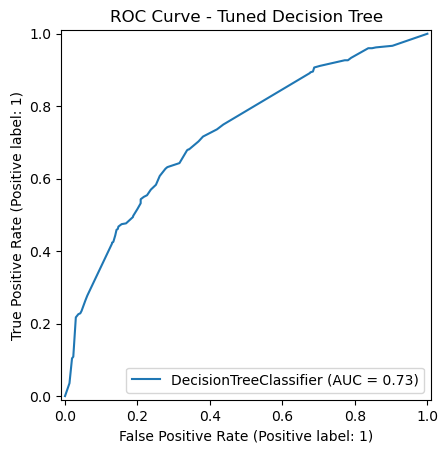

In [63]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(
    dtc_tuned,
    X_test,
    y_test
)

plt.title("ROC Curve - Tuned Decision Tree")
plt.show()

In [65]:
feature_importance = pd.Series(
    dtc_tuned.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

feature_importance.head(10)

Rainfall since 9 am (mm)    0.484103
MSLP (hPa)                  0.118170
WindDir_SSE                 0.055638
Humidity (%)                0.044803
Wind Speed (km/h)           0.044271
Air Temp (degrees C)        0.039600
Dew Pt Temp (degrees C)     0.035840
WindDir_N                   0.031729
WindDir_WSW                 0.029636
WindDir_SSW                 0.018829
dtype: float64

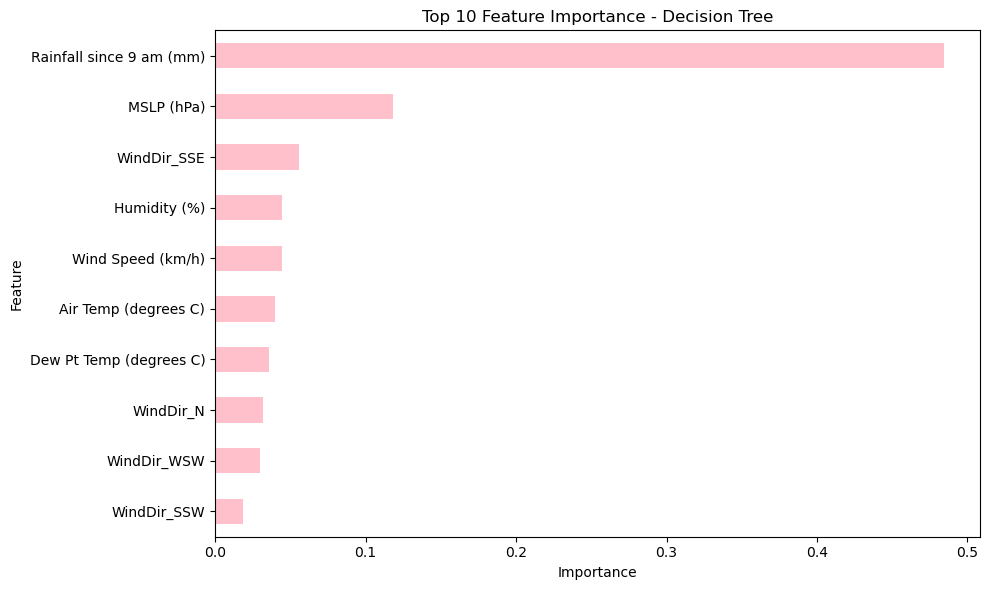

In [67]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(
    kind="barh",
    color="pink"
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importance - Decision Tree")

plt.tight_layout()
plt.show()

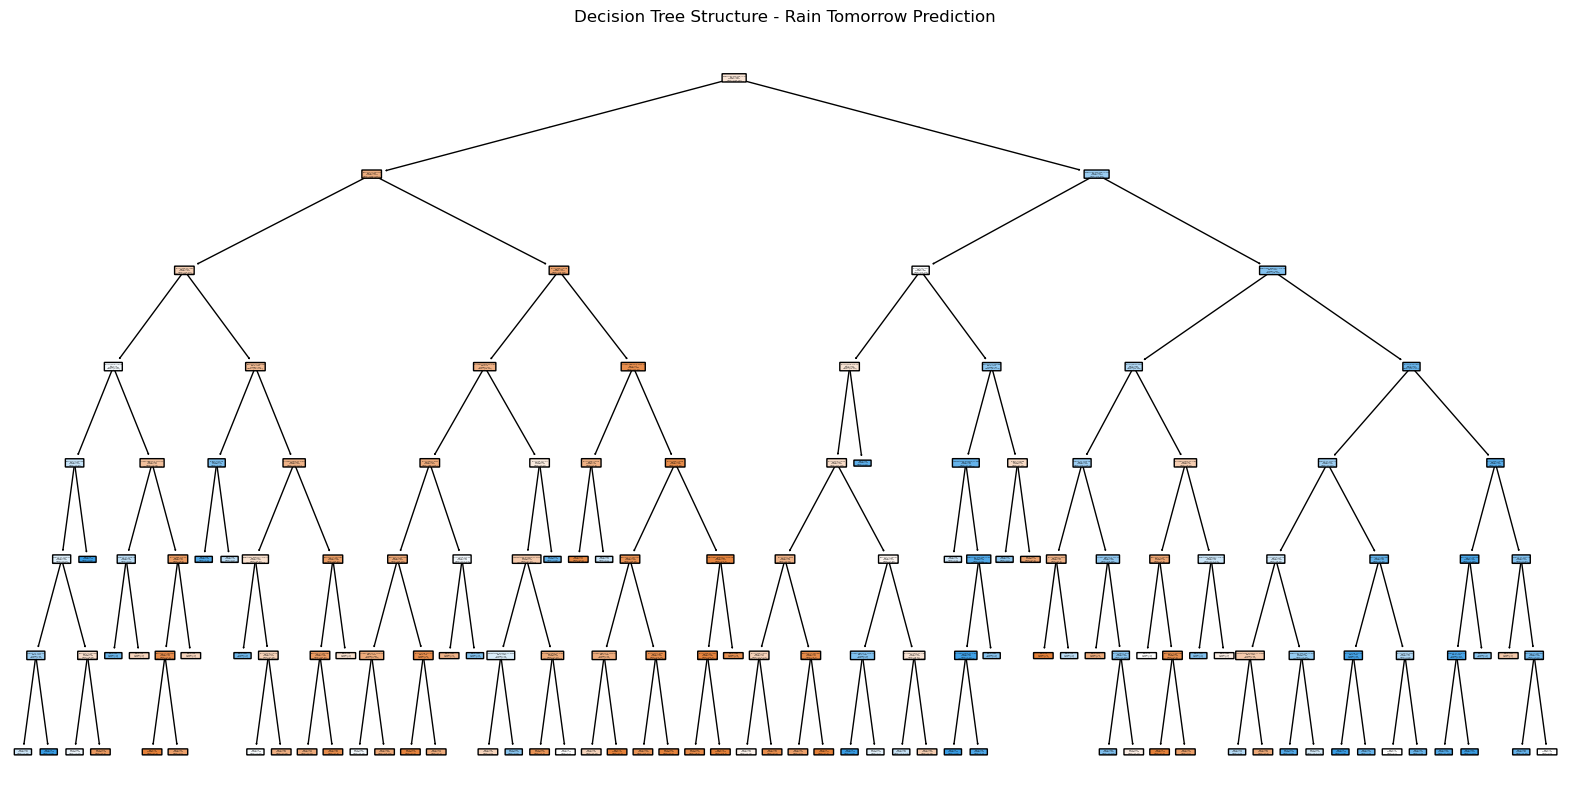

In [69]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(
    dtc_tuned,
    filled=True,
    rounded=True,
    class_names=["No Rain Tomorrow", "Rain Tomorrow"],
    feature_names=X.columns,
    #max_depth=3
)

plt.title("Decision Tree Structure - Rain Tomorrow Prediction")
plt.show()